# 03. Supervised Segmentation 
The goal of this stage is to analyze how individual features reduce uncertainty about the churn outcome using supervised segmentation techniques.

Rather than training a full predictive model, this step focuses on univariate, segmentation-based analysis to understand how different customer attributes partition the population into groups with distinct churn behavior.

This analysis is exploratory and diagnostic in nature. The results are not used directly for feature selection or model training, but to inform subsequent modeling decisions and guide multivariate analysis.

## 3.1. Environment setup

In [1]:
import numpy as np
import pandas as pd
from math import log2

import matplotlib.pyplot as plt
import seaborn as sns

## 3.2. Load prepared training data

In [13]:
X_train = pd.read_csv("../data/X_train.csv")
y_train = pd.read_csv("../data/y_train.csv")["churn"]

### 3.2.1. Quick sanity checks

In [14]:
print(X_train.shape)
print(y_train.shape)

X_train.head(), y_train.head()

(4800, 17)
(4800,)


(   customer_id   plan region    industry  tenure_months  team_size  \
 0         2243  Basic   APAC  Healthcare             31          2   
 1          264  Basic     EU  E-commerce              1          7   
 2         1801    Pro    NaN        SaaS             17          5   
 3         5321  Basic    NaN  E-commerce             39          3   
 4         2076    Pro     EU        SaaS              5          1   
 
    monthly_price  logins_per_week  campaigns_per_month  automation_used  \
 0           9.93             4.17                    6                0   
 1          26.03             5.50                    5                0   
 2          54.52             3.41                    7                1   
 3          16.02             2.56                    5                1   
 4          53.85             1.87                    4                1   
 
    onboarding_completed  integrations_connected  support_tickets_90d  \
 0                     0                 

## 3.3. Base entropy
We first compute the entropy of the target variable (`churn`) on the training set.

This value represents the baseline level of uncertainty about churn **before** considering any features.
All subsequent information gain calculations measure how much individual features reduce this baseline uncertainty.

In [15]:
def entropy(y):
    probs = y.value_counts(normalize=True)
    return -np.sum(probs * np.log2(probs))

base_entropy = entropy(y_train)
base_entropy

np.float64(0.922811132172962)

## 3.4. Segmentation rules
Supervised segmentation is performed to assess feature informativeness prior to any preprocessing or model fitting.

The following rules are applied:

- No imputation is performed; missing values are treated as an explicit category.
- No scaling or normalization is applied, as entropy-based measures depend only on class proportions.
- Categorical features are evaluated in their original form (no one-hot encoding).
- Binary features are segmented directly into two groups (0 / 1).
- Numeric features are discretized using simple, interpretable splits for entropy calculation only.
- All computations are based on training data exclusively.

These choices ensure that entropy and information gain reflect the raw informational structure of the data.

## 3.5. Entropy & Information Gain per feature
For each feature, we compute the entropy of churn across its induced segments and measure the corresponding information gain.

Segment definitions depend on feature type:

- Binary and low-cardinality categorical features are evaluated using their natural value splits.
- Continuous and high-cardinality features require controlled segmentation (binning) to avoid artificially inflated information gain.

This ensures that information gain reflects true discriminatory power rather than over-fragmentation.

### 3.5.1. Helper: Entropy (binary target)
We use Shannon entropy to quantify uncertainty in the binary churn label (0/1).  
This helper is used to compute segment entropies and weighted post-split entropy for Information Gain.

In [27]:
def entropy_binary(y) -> float:
    """
    Shannon entropy for a binary target (0/1).
    Returns value in [0, 1].
    """
    y = pd.Series(y).dropna()

    if len(y) == 0:
        return np.nan

    # Ensure numeric 0/1
    y = y.astype(int)

    p1 = (y == 1).mean()
    p0 = 1 - p1

    entropy = 0.0
    for p in (p0, p1):
        if p > 0:
            entropy -= p * np.log2(p)

    return float(entropy)

In [28]:
print("Entropy([0,0,0,0]) =", entropy_binary([0,0,0,0]))  
print("Entropy([0,1])     =", entropy_binary([0,1]))      
print("Entropy(y_train)   =", entropy_binary(y_train))   

Entropy([0,0,0,0]) = 0.0
Entropy([0,1])     = 1.0
Entropy(y_train)   = 0.922811132172962


In [58]:
def ig_for_manual_segments(
    X: pd.DataFrame,
    y: pd.Series,
    feature: str,
    bins: list,
    labels: list,
    base_entropy: float
) -> tuple[pd.DataFrame, dict]:
    """
    Compute segment-level stats, weighted entropy and IG
    for manually defined numeric thresholds.
    """

    binned = pd.cut(X[feature], bins=bins, labels=labels)

    tmp = pd.DataFrame({
        "segment": binned,
        "churn": y
    })

    N = len(tmp)

    seg_rows = []
    for seg_val, grp in tmp.groupby("segment", dropna=False, observed=True):
        seg_rows.append({
            "feature": feature,
            "segment": str(seg_val),
            "n": len(grp),
            "weight": len(grp) / N,
            "entropy": entropy_binary(grp["churn"]),
            "churn_rate": grp["churn"].mean(),
        })

    seg_df = pd.DataFrame(seg_rows).sort_values("n", ascending=False)

    weighted_entropy = (seg_df["weight"] * seg_df["entropy"]).sum()
    information_gain = base_entropy - weighted_entropy

    summary = {
        "feature": feature,
        "segmentation": "manual",
        "base_entropy": base_entropy,
        "weighted_entropy": weighted_entropy,
        "information_gain": information_gain,
        "n_segments": seg_df.shape[0],
    }

    return seg_df, summary

### 3.5.2. Natural-split Information Gain (binary & low-cardinality categorical)
**Key observations from natural-split Information Gain analysis:**
- No binary or low-cardinality categorical feature provides strong standalone separation for churn in this univariate setup.
- `onboarding_completed` is the most informative simple feature, but the post-split entropy remains close to the base entropy.
- `plan`, `region`, and `industry` produce mixed segments with similar churn rates.
- Overall, univariate categorical splits capture limited signal, motivating controlled segmentation for numeric features and multivariate modeling in subsequent stages.

In [29]:
def ig_natural_split(X: pd.DataFrame, y: pd.Series, feature: str, base_entropy: float) -> dict:
    """
    Information Gain for a feature using its natural value splits (including NaN as a segment).
    Returns both IG summary and the segment table.
    """
    tmp = pd.DataFrame({feature: X[feature], "churn": y}).copy()
    N = len(tmp)

    seg_rows = []
    for val, grp in tmp.groupby(feature, dropna=False):
        seg_rows.append({
            "feature": feature,
            "value": val,
            "n": len(grp),
            "weight": len(grp) / N,
            "entropy": entropy_binary(grp["churn"]),
            "churn_rate": grp["churn"].mean(),
        })

    seg_df = (
        pd.DataFrame(seg_rows)
        .sort_values("n", ascending=False)
        .reset_index(drop=True)
    )

    weighted_entropy = float((seg_df["weight"] * seg_df["entropy"]).sum())
    ig = float(base_entropy - weighted_entropy)

    summary = {
        "feature": feature,
        "base_entropy": float(base_entropy),
        "weighted_entropy": weighted_entropy,
        "information_gain": ig,
        "n_segments": int(seg_df.shape[0]),
    }

    return {"summary": summary, "segments": seg_df}

In [30]:
simple_features = [
    "plan",
    "region",
    "industry",
    "automation_used",
    "onboarding_completed",
    "failed_payments_6m",
    "discount_used",
]

results = []
segments_by_feature = {}

for f in simple_features:
    out = ig_natural_split(X_train, y_train, f, base_entropy)
    results.append(out["summary"])
    segments_by_feature[f] = out["segments"]

ig_simple_df = (
    pd.DataFrame(results)
    .sort_values("information_gain", ascending=False)
    .reset_index(drop=True)
)

ig_simple_df

,feature,base_entropy,weighted_entropy,information_gain,n_segments
0,onboarding_completed,0.922811,0.900621,0.022190,2
1,failed_payments_6m,0.922811,0.913687,0.009125,3
2,plan,0.922811,0.917848,0.004963,4
3,automation_used,0.922811,0.918490,0.004321,2
4,discount_used,0.922811,0.921569,0.001242,2
5,industry,0.922811,0.922089,0.000722,6
6,region,0.922811,0.922624,0.000187,4


In [31]:
segments_by_feature["plan"]

,feature,value,n,weight,entropy,churn_rate
0,plan,Basic,2174,0.452917,0.957022,0.378565
1,plan,Pro,1429,0.297708,0.870154,0.291113
2,plan,Business,876,0.182500,0.913662,0.328767
3,plan,Enterprise,321,0.066875,0.876284,0.295950


### 3.5.3. Controlled segmentation (numeric features)
For numeric and high-cardinality features, Information Gain is computed using controlled segmentation via quantile-based binning.
To ensure comparability across features and prevent over-fragmentation, each numeric feature is discretized into a fixed number of quantile-based bins (quintiles). Missing values are preserved as a separate segment.
This setup provides a standardized baseline for assessing univariate signal strength under controlled segmentation capacity, rather than defining optimal or production-ready splits.

The following numeric features are analyzed using this approach:

- `monthly_price`
- `tenure_months`
- `logins_per_week`
- `campaigns_per_month`
- `avg_response_hours`
- `nps`
- `team_size`
- `integrations_connected`
- `support_tickets_90d`

For each feature, we compute:
- segment-level entropy of churn
- weighted post-split entropy
- information gain relative to the base entropy
- number of bins and missing values

In [32]:
numeric_features = [
    "monthly_price",
    "tenure_months",
    "logins_per_week",
    "campaigns_per_month",
    "avg_response_hours",
    "nps",
    "team_size",
    "integrations_connected",
    "support_tickets_90d",
]

missing_cols = [c for c in numeric_features if c not in X_train.columns]
print("Missing columns in X_train:", missing_cols)

print("Numeric feature count:", len(numeric_features))

Missing columns in X_train: []
Numeric feature count: 9


In [34]:
def make_qcut_bins(s: pd.Series, q: int = 5) -> pd.Series:
    """
    Quantile binning with q bins. Keeps NaN as NaN (will be handled as a separate segment later).
    Returns a categorical Series with Interval bins.
    """
    s_non_null = s.dropna()
    if s_non_null.nunique() < 2:
        return pd.Series([pd.NA] * len(s), index=s.index, dtype="category")
    return pd.qcut(s, q=q, duplicates="drop")

In [37]:
def ig_for_binned_feature(
    X: pd.DataFrame,
    y: pd.Series,
    feature: str,
    base_entropy: float,
    q: int = 5
) -> tuple[dict, pd.DataFrame]:
    """
    Compute Information Gain for a numeric feature using quantile-based binning.

    Returns:
        summary: dict with base_entropy, weighted_entropy, information_gain,
                 number of segments, bins, and missing values
        seg_df: DataFrame with per-segment statistics
    """

    # 1) Apply quantile-based binning (NaNs preserved)
    binned = make_qcut_bins(X[feature], q=q)

    # 2) Build temporary DataFrame with bins and target
    tmp = pd.DataFrame({
        "bin": binned,
        "churn": y
    })

    N = len(tmp)

    # 3) Compute segment-level statistics
    seg_rows = []
    for bin_val, grp in tmp.groupby("bin", dropna=False, observed=True):
        seg_rows.append({
            "feature": feature,
            "segment": str(bin_val),          # interval or NaN
            "n": len(grp),
            "weight": len(grp) / N,
            "entropy": entropy_binary(grp["churn"]),
            "churn_rate": grp["churn"].mean(),
        })

    seg_df = (
        pd.DataFrame(seg_rows)
        .sort_values("n", ascending=False)
        .reset_index(drop=True)
    )

    # 4) Compute weighted post-split entropy and information gain
    weighted_entropy = float((seg_df["weight"] * seg_df["entropy"]).sum())
    information_gain = float(base_entropy - weighted_entropy)

    # 5) Metadata and sanity checks
    n_missing = int(tmp["bin"].isna().sum())
    n_bins = int(pd.Series(binned).dropna().nunique())
    n_segments = int(seg_df.shape[0])  # bins + missing segment (if present)

    summary = {
        "feature": feature,
        "base_entropy": base_entropy,
        "weighted_entropy": weighted_entropy,
        "information_gain": information_gain,
        "n_segments": n_segments,
        "n_bins": n_bins,
        "n_missing": n_missing,
    }

    return summary, seg_df

#### 
The table below reports Information Gain for numeric features under uniform quantile-based segmentation (q = 5), serving as a controlled baseline for univariate comparison rather than a final segmentation strategy.

In [38]:
binned_results = []
segments_binned_by_feature = {}

for f in numeric_features:
    summary, seg_df = ig_for_binned_feature(
        X=X_train,
        y=y_train,
        feature=f,
        base_entropy=base_entropy,
        q=5
    )
    binned_results.append(summary)
    segments_binned_by_feature[f] = seg_df

ig_binned_df = (
    pd.DataFrame(binned_results)
    .sort_values("information_gain", ascending=False)
    .reset_index(drop=True)
)

ig_binned_df

,feature,base_entropy,weighted_entropy,information_gain,n_segments,n_bins,n_missing
0,tenure_months,0.922811,0.860666,0.062145,5,5,0
1,logins_per_week,0.922811,0.917862,0.004949,5,5,0
2,monthly_price,0.922811,0.918042,0.004769,6,5,111
3,nps,0.922811,0.918294,0.004517,6,5,1187
4,integrations_connected,0.922811,0.920232,0.002580,3,3,0
5,avg_response_hours,0.922811,0.920453,0.002358,6,5,1460
6,support_tickets_90d,0.922811,0.920697,0.002114,3,3,0
7,campaigns_per_month,0.922811,0.921702,0.001109,5,5,0
8,team_size,0.922811,0.922792,0.000019,5,5,0


In [39]:
ig_binned_df[["feature", "n_bins", "n_missing", "information_gain"]]

,feature,n_bins,n_missing,information_gain
0,tenure_months,5,0,0.062145
1,logins_per_week,5,0,0.004949
2,monthly_price,5,111,0.004769
3,nps,5,1187,0.004517
4,integrations_connected,3,0,0.002580
5,avg_response_hours,5,1460,0.002358
6,support_tickets_90d,3,0,0.002114
7,campaigns_per_month,5,0,0.001109
8,team_size,5,0,0.000019


In [40]:
top_feature = ig_binned_df.loc[0, "feature"]
print("Top binned feature:", top_feature)

segments_binned_by_feature[top_feature]

Top binned feature: tenure_months


,feature,segment,n,weight,entropy,churn_rate
0,tenure_months,"(0.999, 10.0]",999,0.208125,0.997650,0.528529
1,tenure_months,"(10.0, 20.0]",986,0.205417,0.989289,0.439148
2,tenure_months,"(20.0, 30.0]",965,0.201042,0.902341,0.318135
3,tenure_months,"(30.0, 39.0]",936,0.195000,0.781201,0.231838
4,tenure_months,"(39.0, 48.0]",914,0.190417,0.609566,0.149891


#### 3.5.3.1. Interpretation
Under uniform quantile-based segmentation, most numeric features exhibit limited information gain, with relatively high entropy persisting across bins.

This suggests that automatic quantile splits do not align well with meaningful churn thresholds for several features. While variables such as `tenure_months` show stronger signal even under this constraint, others require more tailored segmentation to reveal their discriminatory power.

Consequently, quantile-based binning is treated as a baseline rather than a final strategy. In the next step, we perform feature-specific manual segmentation to identify more informative thresholds.

###  3.5.4.Feature-specific threshold exploration (manual segmentation)
Following controlled quantile-based segmentation, we perform feature-specific manual threshold exploration for numeric features.

The goal of this step is not to optimize Information Gain, but to identify interpretable and semantically meaningful segmentations that better reflect how each feature relates to churn.

Manual segmentation is guided by:
- feature semantics (lifecycle, pricing, engagement, operational signals),
- distributional structure,
- observed churn trends across the feature range.

All segmentation decisions are evaluated using Information Gain for diagnostic comparison only, and are based exclusively on the training data.

#### 3.5.4.1 Feature-specific threshold exploration: tenure_months
The `tenure_months` feature reflects customer lifecycle progression rather than discrete behavioral or pricing tiers.

Its distribution is relatively smooth, with churn exhibiting a largely monotonic decline as tenure increases. As a result, aggressively optimizing split points is neither necessary nor conceptually meaningful.

Instead, we apply lifecycle-aligned manual segmentation to reflect interpretable customer stages.

**Lifecycle-aligned segmentation:**
- ≤10 — early lifecycle
- 11–20 — early retention
- 21–30 — established
- 31–40 — mature
- more than 40 — long-term

In [96]:
X_train["tenure_months"].describe()

count    4800.000000
mean       24.606042
std        13.974674
min         1.000000
25%        12.000000
50%        25.000000
75%        37.000000
max        48.000000
Name: tenure_months, dtype: float64

In [101]:
X_train["tenure_months"].quantile(
    [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

0.01     1.0
0.05     3.0
0.10     5.0
0.25    12.0
0.50    25.0
0.75    37.0
0.90    44.0
0.95    46.0
0.99    48.0
Name: tenure_months, dtype: float64

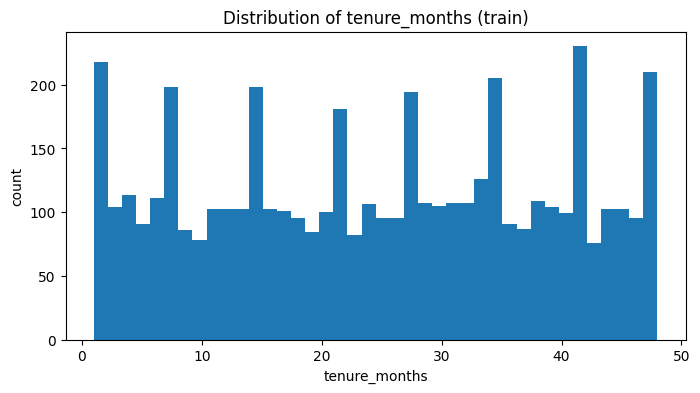

In [102]:
plt.figure(figsize=(8, 4))
plt.hist(X_train["tenure_months"].dropna(), bins=40)
plt.xlabel("tenure_months")
plt.ylabel("count")
plt.title("Distribution of tenure_months (train)")
plt.show()

In [103]:
tenure_bins = [-float("inf"), 10, 20, 30, 40, float("inf")]
tenure_labels = ["≤10", "11–20", "21–30", "31–40", ">40"]

seg_tenure, summary_tenure = ig_for_manual_segments(
    X=X_train,
    y=y_train,
    feature="tenure_months",
    bins=tenure_bins,
    labels=tenure_labels,
    base_entropy=base_entropy
)

seg_tenure
pd.DataFrame([summary_tenure]).round(6)

,feature,segmentation,base_entropy,weighted_entropy,information_gain,n_segments
0,tenure_months,manual,0.922811,0.8609,0.061911,5


#### 3.5.4.2 Feature-specific threshold exploration: monthly_price
Across multiple semantically plausible manual segmentations, Information Gain for `monthly_price` remains consistently low.

This stability indicates that pricing tier alone provides limited univariate separation for churn. Differences in churn behavior across price segments are present but modest and do not define sharp decision boundaries.

Accordingly, `monthly_price` is treated as a secondary signal whose contribution is likely conditional on customer lifecycle and engagement features rather than acting as a standalone churn driver.

In [104]:
X_train["monthly_price"].describe()

count    4689.000000
mean       53.549891
std        52.146371
min         9.000000
25%        19.740000
50%        39.890000
75%        61.280000
max       273.880000
Name: monthly_price, dtype: float64

In [105]:
X_train["monthly_price"].quantile(
    [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

0.01      9.0000
0.05      9.0000
0.10     12.6260
0.25     19.7400
0.50     39.8900
0.75     61.2800
0.90    103.1600
0.95    114.9320
0.99    254.9536
Name: monthly_price, dtype: float64

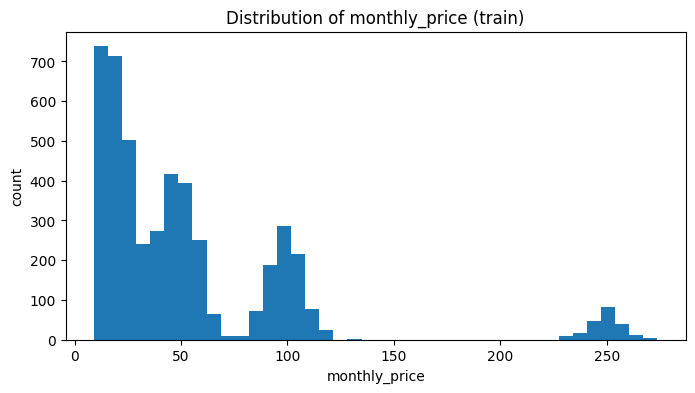

In [106]:
plt.figure(figsize=(8, 4))
plt.hist(X_train["monthly_price"].dropna(), bins=40)
plt.xlabel("monthly_price")
plt.ylabel("count")
plt.title("Distribution of monthly_price (train)")
plt.show()

In [108]:
price_bins_v2 = [-float("inf"), 20, 60, 120, float("inf")]
price_labels_v2 = ["≤20", "21–60", "61–120", ">120"]

seg_price, summary_price = ig_for_manual_segments(
    X=X_train,
    y=y_train,
    feature="monthly_price",
    bins=price_bins,
    labels=price_labels,
    base_entropy=base_entropy
)

seg_price
pd.DataFrame([summary_price]).round(6)

,feature,segmentation,base_entropy,weighted_entropy,information_gain,n_segments
0,monthly_price,manual,0.922811,0.919344,0.003467,6


#### 3.5.4.3 Feature-specific threshold exploration: logins_per_week
The `logins_per_week` feature captures habitual product engagement intensity.

Manual segmentation aligned with behavioral usage levels (inactive → power users) produces stable Information Gain comparable to quantile-based binning, indicating a consistent but moderate univariate signal.

While `logins_per_week` does not strongly reduce churn uncertainty on its own, its monotonic relationship with churn and stable behavior across segmentations suggest it is an important supporting feature in multi-feature models.

In [109]:
X_train["logins_per_week"].describe()

count    4800.000000
mean        3.529592
std         1.763961
min         0.000000
25%         2.290000
50%         3.500000
75%         4.720000
max        10.190000
Name: logins_per_week, dtype: float64

In [110]:
X_train["logins_per_week"].quantile(
    [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

0.01    0.0000
0.05    0.5795
0.10    1.2000
0.25    2.2900
0.50    3.5000
0.75    4.7200
0.90    5.8500
0.95    6.4805
0.99    7.7001
Name: logins_per_week, dtype: float64

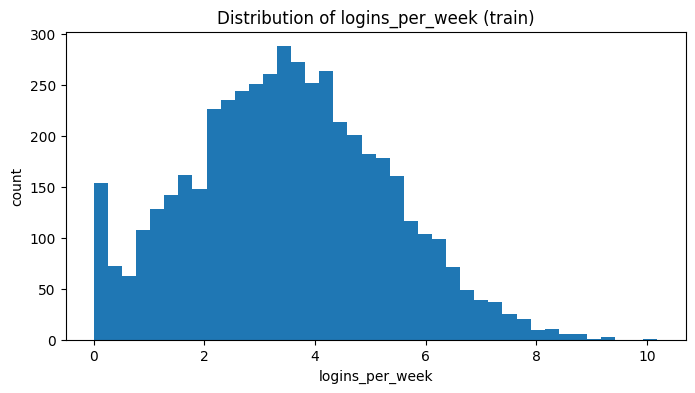

In [111]:
plt.figure(figsize=(8, 4))
plt.hist(X_train["logins_per_week"].dropna(), bins=40)
plt.xlabel("logins_per_week")
plt.ylabel("count")
plt.title("Distribution of logins_per_week (train)")
plt.show()

In [121]:
logins_bins = [-float("inf"), 1, 3, 5, 7, float("inf")]
logins_labels = ["≤1", "2–3", "4–5", "6–7", ">7"]

seg_logins, summary_logins = ig_for_manual_segments(
    X=X_train,
    y=y_train,
    feature="logins_per_week",
    bins=logins_bins,
    labels=logins_labels,
    base_entropy=base_entropy
)

seg_logins
pd.DataFrame([summary_logins]).round(6)

,feature,segmentation,base_entropy,weighted_entropy,information_gain,n_segments
0,logins_per_week,manual,0.922811,0.918118,0.004693,5


#### 3.5.4.4 Feature-specific threshold exploration: campaigns_per_month
Across multiple activity-based segmentations, `campaigns_per_month` exhibits very low Information Gain.
Even under optimized thresholding, the feature reduces uncertainty about churn only marginally.

This indicates that campaign volume alone is not a strong univariate discriminator.
While higher activity levels are directionally associated with lower churn, the separation is weak and continuous rather than threshold-driven.

A simple activity-level segmentation is retained for interpretability, with the understanding that this feature is likely to contribute primarily through interactions with other engagement signals rather than as a standalone predictor.

In [122]:
X_train["campaigns_per_month"].describe()

count    4800.000000
mean        6.015625
std         2.471839
min         0.000000
25%         4.000000
50%         6.000000
75%         8.000000
max        16.000000
Name: campaigns_per_month, dtype: float64

In [129]:
X_train["campaigns_per_month"].quantile(
    [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

0.01     1.0
0.05     2.0
0.10     3.0
0.25     4.0
0.50     6.0
0.75     8.0
0.90     9.0
0.95    10.0
0.99    12.0
Name: campaigns_per_month, dtype: float64

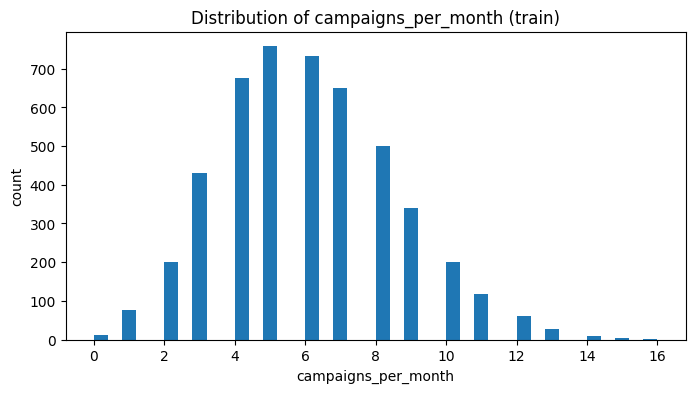

In [132]:
plt.figure(figsize=(8, 4))
plt.hist(X_train["campaigns_per_month"].dropna(), bins=40)
plt.xlabel("campaigns_per_month")
plt.ylabel("count")
plt.title("Distribution of campaigns_per_month (train)")
plt.show()

In [133]:
campaign_bins_A = [-float("inf"), 1, 3, 6, 9, float("inf")]
campaign_labels_A = ["≤1", "2–3", "4–6", "7–9", "≥10"]

seg_campaign_A, summary_campaign_A = ig_for_manual_segments(
    X=X_train,
    y=y_train,
    feature="campaigns_per_month",
    bins=campaign_bins_A,
    labels=campaign_labels_A,
    base_entropy=base_entropy
)

seg_campaign_A
pd.DataFrame([summary_campaign_A]).round(6)

,feature,segmentation,base_entropy,weighted_entropy,information_gain,n_segments
0,campaigns_per_month,manual,0.922811,0.9222,0.000611,5


#### 3.5.4.5 Feature-specific threshold exploration: avg_response_hours
Under service-level–aligned manual segmentation, `avg_response_hours` achieves a modest but non-zero Information Gain.
The result confirms that response time alone provides limited separation, yet contributes meaningful signal when slow response thresholds are crossed.

This behavior is consistent with support quality acting as a secondary churn driver that interacts with engagement and lifecycle factors rather than operating as a primary standalone predictor.

In [136]:
X_train["avg_response_hours"].describe()

count    3340.000000
mean       11.660689
std         4.232632
min         2.900000
25%         8.675000
50%        11.000000
75%        13.900000
max        39.100000
Name: avg_response_hours, dtype: float64

In [137]:
X_train["avg_response_hours"].quantile(
    [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

0.01     4.939
0.05     6.200
0.10     7.000
0.25     8.675
0.50    11.000
0.75    13.900
0.90    17.400
0.95    19.400
0.99    25.022
Name: avg_response_hours, dtype: float64

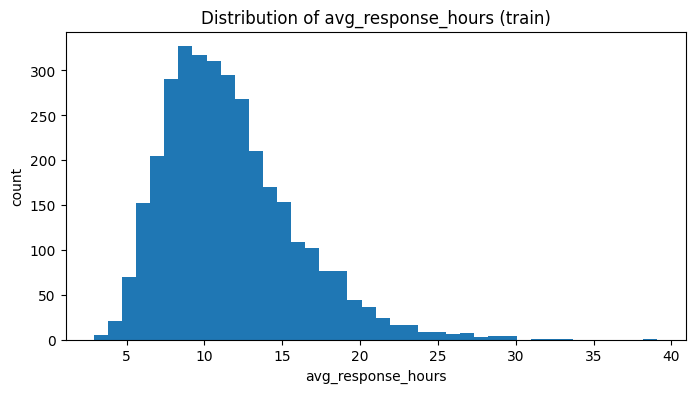

In [138]:
plt.figure(figsize=(8, 4))
plt.hist(X_train["avg_response_hours"].dropna(), bins=40)
plt.xlabel("avg_response_hours")
plt.ylabel("count")
plt.title("Distribution of avg_response_hours (train)")
plt.show()

In [139]:
response_bins = [-float("inf"), 8, 12, 17, float("inf")]
response_labels = ["≤8h", "9–12h", "13–17h", ">17h"]

seg_response, summary_response = ig_for_manual_segments(
    X=X_train,
    y=y_train,
    feature="avg_response_hours",
    bins=response_bins,
    labels=response_labels,
    base_entropy=base_entropy
)

seg_response
pd.DataFrame([summary_response]).round(6)

,feature,segmentation,base_entropy,weighted_entropy,information_gain,n_segments
0,avg_response_hours,manual,0.922811,0.92108,0.001731,5


#### 3.5.4.6 Feature-specific threshold exploration: nps
Using standard NPS segmentation (Detractors / Passives / Promoters), the feature exhibits moderate Information Gain.

While NPS does not provide strong standalone separation, it consistently reduces churn uncertainty across well-established satisfaction categories. This confirms NPS as a secondary but reliable churn signal that complements behavioral and lifecycle features rather than replacing them.

The use of canonical NPS thresholds prioritizes interpretability and business alignment over marginal gains from threshold optimization.

In [140]:
X_train["nps"].describe()

count    3613.000000
mean       28.189316
std        20.189046
min       -39.000000
25%        14.000000
50%        28.000000
75%        42.000000
max       100.000000
Name: nps, dtype: float64

In [141]:
X_train["nps"].quantile(
    [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

0.01   -19.0
0.05    -4.0
0.10     3.0
0.25    14.0
0.50    28.0
0.75    42.0
0.90    54.0
0.95    62.0
0.99    78.0
Name: nps, dtype: float64

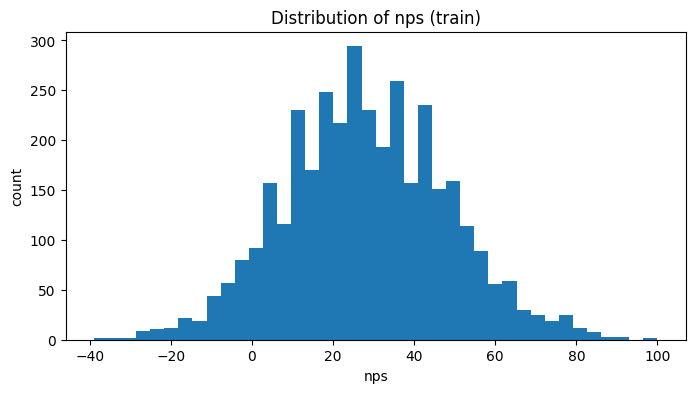

In [142]:
plt.figure(figsize=(8, 4))
plt.hist(X_train["nps"].dropna(), bins=40)
plt.xlabel("nps")
plt.ylabel("count")
plt.title("Distribution of nps (train)")
plt.show()

In [144]:
nps_bins = [-float("inf"), 0, 30, float("inf")]
nps_labels = ["Detractors", "Passives", "Promoters"]

seg_nps, summary_nps = ig_for_manual_segments(
    X=X_train,
    y=y_train,
    feature="nps",
    bins=nps_bins,
    labels=nps_labels,
    base_entropy=base_entropy
)
seg_nps
pd.DataFrame([summary_nps]).round(6)

,feature,segmentation,base_entropy,weighted_entropy,information_gain,n_segments
0,nps,manual,0.922811,0.919542,0.003269,4


#### 3.5.4.7 Feature-specific threshold exploration: support_tickets_90d
The `support_tickets_90d` feature captures operational friction rather than sustained behavioral patterns.

Manual segmentation into zero, moderate (1–2), and high (3+) ticket volume reflects natural escalation levels and yields stable but limited Information Gain. This indicates that support volume alone does not strongly discriminate churn risk, but serves as a secondary signal that complements engagement and lifecycle features.

The chosen segmentation prioritizes interpretability and robustness over marginal gains from over-fragmentation.

In [145]:
X_train["support_tickets_90d"].describe()

count    4800.000000
mean        1.209167
std         1.111421
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         7.000000
Name: support_tickets_90d, dtype: float64

In [146]:
X_train["support_tickets_90d"].quantile(
    [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

0.01    0.0
0.05    0.0
0.10    0.0
0.25    0.0
0.50    1.0
0.75    2.0
0.90    3.0
0.95    3.0
0.99    4.0
Name: support_tickets_90d, dtype: float64

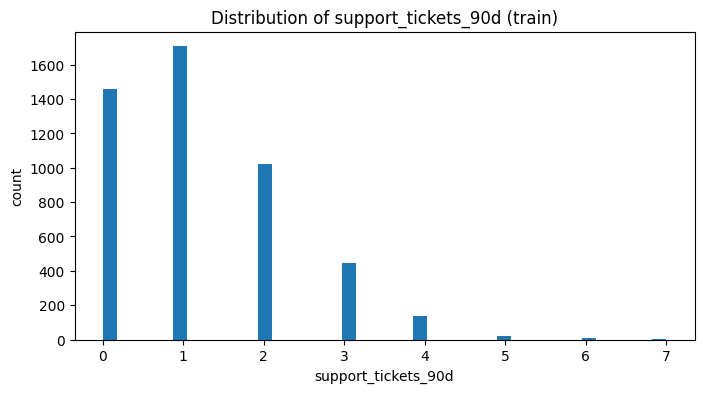

In [147]:
plt.figure(figsize=(8, 4))
plt.hist(X_train["support_tickets_90d"].dropna(), bins=40)
plt.xlabel("support_tickets_90d")
plt.ylabel("count")
plt.title("Distribution of support_tickets_90d (train)")
plt.show()

In [148]:
tickets_bins = [-float("inf"), 0, 2, float("inf")]
tickets_labels = ["0", "1–2", "3+"]

seg_tickets, summary_tickets = ig_for_manual_segments(
    X=X_train,
    y=y_train,
    feature="support_tickets_90d",
    bins=tickets_bins,
    labels=tickets_labels,
    base_entropy=base_entropy
)

seg_tickets
pd.DataFrame([summary_tickets]).round(6)

,feature,segmentation,base_entropy,weighted_entropy,information_gain,n_segments
0,support_tickets_90d,manual,0.922811,0.919872,0.002939,3


#### 3.5.4.8 Feature-specific threshold exploration: integrations_connected
The `integrations_connected` feature captures technical lock-in and switching costs rather than direct engagement intensity.

Given the highly discrete and right-skewed distribution, the feature is segmented into three interpretable levels: no integrations (0), minimal setup (1), and multiple integrations (2+). This coarse segmentation avoids sparse tail fragmentation while preserving the core business meaning of increasing adoption depth.

Under this setup, `integrations_connected` provides modest Information Gain, indicating it is a secondary churn signal that is most useful in combination with lifecycle and usage features.

In [149]:
X_train["integrations_connected"].describe()

count    4800.000000
mean        1.495417
std         1.291444
min         0.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         9.000000
Name: integrations_connected, dtype: float64

In [150]:
X_train["integrations_connected"].quantile(
    [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

0.01    0.0
0.05    0.0
0.10    0.0
0.25    1.0
0.50    1.0
0.75    2.0
0.90    3.0
0.95    4.0
0.99    5.0
Name: integrations_connected, dtype: float64

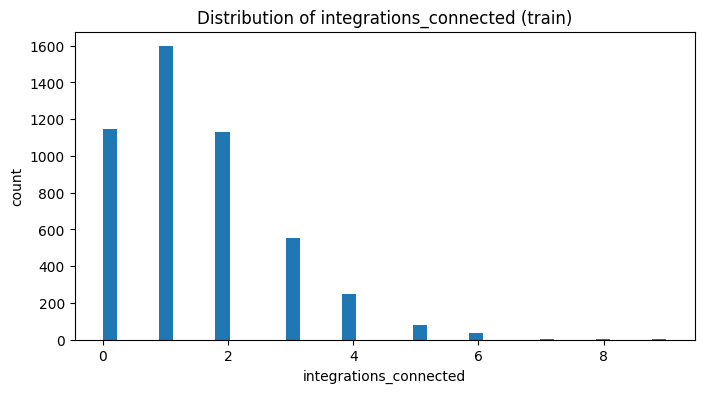

In [151]:
plt.figure(figsize=(8, 4))
plt.hist(X_train["integrations_connected"].dropna(), bins=40)
plt.xlabel("integrations_connected")
plt.ylabel("count")
plt.title("Distribution of integrations_connected (train)")
plt.show()

In [153]:
integrations_bins = [-float("inf"), 0, 1, float("inf")]
integrations_labels = ["0", "1", "2+"]

seg_integrations, summary_integrations = ig_for_manual_segments(
    X=X_train,
    y=y_train,
    feature="integrations_connected",
    bins=integrations_bins,
    labels=integrations_labels,
    base_entropy=base_entropy
)

seg_integrations
pd.DataFrame([summary_integrations]).round(6)

,feature,segmentation,base_entropy,weighted_entropy,information_gain,n_segments
0,integrations_connected,manual,0.922811,0.920364,0.002447,3


### 3.6. Consolidated Information Gain Summary

This section consolidates Information Gain results across:
- natural-split features (binary + low-cardinality categorical), and
- manually segmented numeric features.

Values reflect **univariate** signal only and are used for diagnostic comparison (not as a standalone feature selection rule).

In [159]:
ig_natural = ig_simple_df.copy()
ig_natural["feature_type"] = ig_natural["feature"].map(
    lambda f: "binary" if f in {"automation_used", "onboarding_completed", "discount_used"} else "categorical"
)
ig_natural["segmentation_type"] = "natural"
ig_natural = ig_natural[["feature", "feature_type", "segmentation_type", "n_segments", "information_gain"]]
manual_summaries = [
    summary_tenure,           
    summary_logins,           
    summary_price,             
    summary_campaign_A,    
    summary_response,   
    summary_nps,                      
    summary_tickets,           
    summary_integrations,     
]

ig_manual = pd.DataFrame(manual_summaries).copy()
ig_manual["feature_type"] = "numeric"
ig_manual["segmentation_type"] = "manual"
ig_manual = ig_manual.rename(columns={"n_segments": "n_segments"})
ig_manual = ig_manual[["feature", "feature_type", "segmentation_type", "n_segments", "information_gain"]]

ig_summary = (
    pd.concat([ig_natural, ig_manual], ignore_index=True)
    .sort_values("information_gain", ascending=False)
    .reset_index(drop=True)
)

ig_summary.round(6)

,feature,feature_type,segmentation_type,n_segments,information_gain
0,tenure_months,numeric,manual,5,0.061911
1,onboarding_completed,binary,natural,2,0.022190
2,failed_payments_6m,categorical,natural,3,0.009125
3,plan,categorical,natural,4,0.004963
4,logins_per_week,numeric,manual,5,0.004693
5,automation_used,binary,natural,2,0.004321
6,monthly_price,numeric,manual,6,0.003467
7,nps,numeric,manual,4,0.003269
8,support_tickets_90d,numeric,manual,3,0.002939
9,integrations_connected,numeric,manual,3,0.002447
